# 04 — Full-Wave EM Simulation (OpenEMS FDTD + S-parameter Extraction)

Takes the binary pixel layout from **03_layout_gds.ipynb**, simulates it with **OpenEMS** (FDTD), extracts S₁₁, and compares against the trained surrogate and PixelAnt MoM ground truth.

**openEMS** must be built from source for the Python 3.13 venv — see [docs/installation.md](../../docs/installation.md#openems-pixelatedrf-notebooks-only).

## Simulation substrate: FR4 PCB (matches training data)

The training dataset (`antenna_dataset.mat`) was generated with **MATLAB Antenna Toolbox MoM on FR4**, so the FDTD must use the same substrate for meaningful comparison.

| Parameter | Value |
|-----------|-------|
| Substrate | FR4 (εr = 4.4, tanδ = 0.02) |
| Thickness | 1.6 mm (standard PCB) |
| Patch metal | PEC, 35 µm (1oz Cu) |
| Ground plane | Full PEC at bottom of FR4 |
| Feed | Lumped port, 50 Ω, center-bottom edge |
| Pixel size | 700 µm (GF180 physical) |

> **Previous GF180/Si setup was wrong:** The port spanned 350 µm of lossy Si (σ = 10 S/m) — 5 skin depths at 5 GHz — completely screening the resonant patch, causing flat S₁₁ ≈ −7.5 dB. FR4 is non-lossy so the port correctly couples to the patch.

In [1]:
import os, tempfile
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import skrf as rf

NB_DIR    = Path(os.path.abspath(''))
MODEL_DIR = NB_DIR / 'models'
GDS_DIR   = NB_DIR / 'gds_output'

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
GRID_DIM = 12
N_PIXELS = GRID_DIM ** 2
N_FREQ   = 81

# ── Check OpenEMS availability ─────────────────────────────────────────────────
try:
    import openEMS
    from openEMS import openEMS as FDTD_class
    from CSXCAD import ContinuousStructure
    OPENEMS_OK = True
    print(f'openEMS : {openEMS.__version__}')
except ImportError as e:
    OPENEMS_OK = False
    print(f'openEMS NOT found: {e}')
    print('Build from source for Python 3.13 — see docs/installation.md')
    print('Sections below will show simulation setup code but skip execution.')

print(f'scikit-rf : {rf.__version__}')

openEMS : 0.0.36
scikit-rf : 1.12.0


ForwardSurrogateNet v4 (cnn_ch=48, n_res=3) loaded.
ConditionalGenerator v5b (product-gated) loaded.
Test sample #63964: min=-20.2 dB @ 7.9 GHz


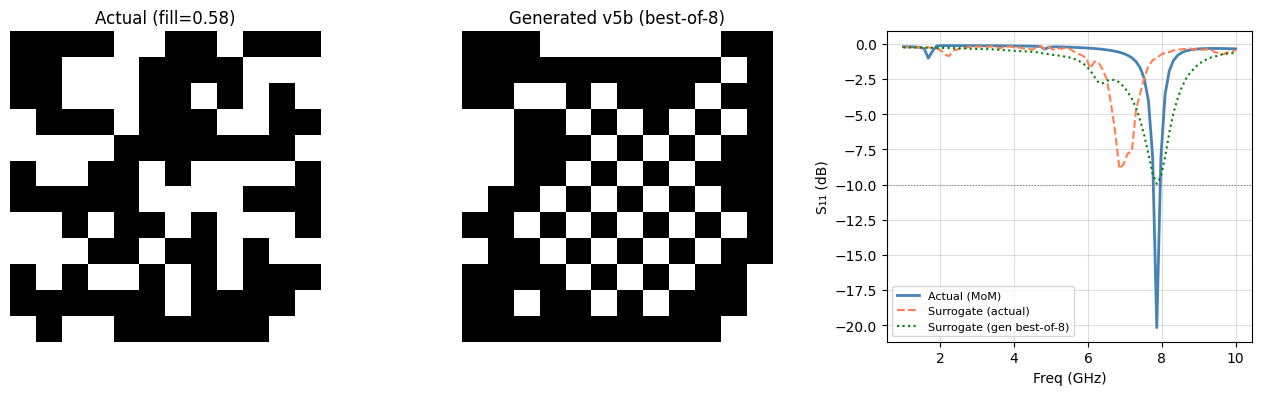

Surrogate RMSE actual: 3.115 dB
Surrogate RMSE gen→target: 1.957 dB


In [2]:
import torch.nn.functional as F

# ── Building blocks (must match 02_train.ipynb exactly) ───────────────────────

class ResBlock1D(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.ff   = nn.Sequential(nn.Linear(dim, dim*2), nn.GELU(), nn.Dropout(dropout),
                                  nn.Linear(dim*2, dim), nn.Dropout(dropout))
    def forward(self, x): return x + self.ff(self.norm(x))

class SpatialResBlock(nn.Module):
    def __init__(self, ch, groups=8):
        super().__init__()
        g = min(groups, ch)
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch), nn.GELU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch),
        )
    def forward(self, x): return F.gelu(x + self.block(x))

class SEBlock(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        self.fc = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                nn.Linear(ch, max(ch//r, 4)), nn.GELU(),
                                nn.Linear(max(ch//r, 4), ch), nn.Sigmoid())
    def forward(self, x): return x * self.fc(x).view(-1, x.size(1), 1, 1)

class SpatialResBlockSE(nn.Module):
    def __init__(self, ch, groups=8):
        super().__init__()
        g = min(groups, ch)
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch), nn.GELU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.GroupNorm(g, ch))
        self.se = SEBlock(ch)
    def forward(self, x): return F.gelu(x + self.se(self.block(x)))


# ── ForwardSurrogateNet v4 (cnn_ch=48, n_res=3, 6-block head) ─────────────────

class ForwardSurrogateNet(nn.Module):
    def __init__(self, grid_dim=12, n_freq=81, cnn_ch=48, hidden=512, n_res=3):
        super().__init__()
        self.grid_dim = grid_dim
        self.stage1 = nn.Sequential(nn.Conv2d(3, cnn_ch, 3, padding=1, bias=False),
                                    nn.GroupNorm(min(8, cnn_ch), cnn_ch), nn.GELU(),
                                    *[SpatialResBlockSE(cnn_ch) for _ in range(n_res)])
        self.down1  = nn.Sequential(nn.Conv2d(cnn_ch, cnn_ch*2, 3, stride=2, padding=1, bias=False),
                                    nn.GroupNorm(min(8, cnn_ch*2), cnn_ch*2), nn.GELU())
        self.stage2 = nn.Sequential(*[SpatialResBlockSE(cnn_ch*2) for _ in range(n_res)])
        self.down2  = nn.Sequential(nn.Conv2d(cnn_ch*2, cnn_ch*4, 3, stride=2, padding=1, bias=False),
                                    nn.GroupNorm(min(8, cnn_ch*4), cnn_ch*4), nn.GELU())
        self.stage3 = nn.Sequential(*[SpatialResBlockSE(cnn_ch*4) for _ in range(n_res)])
        ms_dim = cnn_ch + cnn_ch*2 + cnn_ch*4*3*3
        self.head = nn.Sequential(nn.Linear(ms_dim, hidden), nn.GELU(), nn.Dropout(0.10),
                                  *[ResBlock1D(hidden, dropout=0.10) for _ in range(6)],
                                  nn.Linear(hidden, n_freq))
    def _add_coords(self, x):
        B, _, H, W = x.shape
        rows = torch.linspace(-1, 1, H, device=x.device).view(1,1,H,1).expand(B,1,H,W)
        cols = torch.linspace(-1, 1, W, device=x.device).view(1,1,1,W).expand(B,1,H,W)
        return torch.cat([x, rows, cols], dim=1)
    def forward(self, x):
        if x.dim() == 2:   x = x.view(-1, 1, self.grid_dim, self.grid_dim)
        elif x.dim() == 3: x = x.unsqueeze(1)
        x = self._add_coords(x)
        f1 = self.stage1(x); f2 = self.stage2(self.down1(f1)); f3 = self.stage3(self.down2(f2))
        return self.head(torch.cat([f1.mean((-2,-1)), f2.mean((-2,-1)), f3.flatten(1)], dim=1))


# ── ConditionalGenerator v5b (product-gated cVAE) ─────────────────────────────

class ConditionalGenerator(nn.Module):
    def __init__(self, n_freq=81, grid_dim=12, latent_dim=64, cnn_ch=48, hidden=256):
        super().__init__()
        self.latent_dim = latent_dim; self.grid_dim = grid_dim
        seed_ch = cnn_ch * 4; self.seed_ch = seed_ch
        self.enc_cnn = nn.Sequential(
            nn.Conv2d(1, cnn_ch, 3, padding=1, bias=False), nn.GroupNorm(8, cnn_ch), nn.GELU(), SpatialResBlock(cnn_ch),
            nn.Conv2d(cnn_ch, cnn_ch*2, 3, stride=2, padding=1, bias=False), nn.GroupNorm(8, cnn_ch*2), nn.GELU(), SpatialResBlock(cnn_ch*2),
            nn.Conv2d(cnn_ch*2, cnn_ch*4, 3, stride=2, padding=1, bias=False), nn.GroupNorm(8, cnn_ch*4), nn.GELU(),
        )
        enc_feat = cnn_ch * 4 * 3 * 3
        self.enc_s11 = nn.Sequential(nn.Linear(n_freq, hidden), nn.GELU(), ResBlock1D(hidden))
        self.enc_fc  = nn.Sequential(nn.Linear(enc_feat + hidden, hidden), nn.GELU(), ResBlock1D(hidden))
        self.fc_mu   = nn.Linear(hidden, latent_dim)
        self.fc_lv   = nn.Linear(hidden, latent_dim)
        self.s11_enc   = nn.Sequential(nn.Linear(n_freq, hidden), nn.GELU(), ResBlock1D(hidden), ResBlock1D(hidden))
        self.z_enc     = nn.Sequential(nn.Linear(latent_dim, hidden), nn.GELU(), ResBlock1D(hidden), ResBlock1D(hidden))
        self.seed_proj = nn.Linear(hidden, seed_ch * 3 * 3)
        self.z_inj = nn.ModuleList([nn.Linear(hidden, seed_ch), nn.Linear(hidden, cnn_ch*2), nn.Linear(hidden, cnn_ch)])
        self.conv1 = SpatialResBlock(seed_ch)
        self.up1   = nn.Sequential(nn.ConvTranspose2d(seed_ch, cnn_ch*2, 4, stride=2, padding=1, bias=False), nn.GroupNorm(8, cnn_ch*2), nn.GELU())
        self.conv2 = SpatialResBlock(cnn_ch*2)
        self.up2   = nn.Sequential(nn.ConvTranspose2d(cnn_ch*2, cnn_ch, 4, stride=2, padding=1, bias=False), nn.GroupNorm(8, cnn_ch), nn.GELU())
        self.conv3 = SpatialResBlock(cnn_ch); self.head = nn.Conv2d(cnn_ch, 1, 1)

    def decode(self, z, s11, tau=0.5):
        B = len(z); s_h = self.s11_enc(s11); z_h = self.z_enc(z)
        seed = F.gelu(self.seed_proj(s_h * z_h)).view(B, self.seed_ch, 3, 3)
        x = self.conv1(seed) + self.z_inj[0](z_h).view(B, -1, 1, 1); x = self.up1(x)
        x = self.conv2(x) + self.z_inj[1](z_h).view(B, -1, 1, 1); x = self.up2(x)
        x = self.conv3(x) + self.z_inj[2](z_h).view(B, -1, 1, 1)
        logits = self.head(x).squeeze(1)
        return torch.sigmoid(logits), logits

    def sample(self, s11, k=1, tau=0.5):
        z = torch.randn(k, self.latent_dim, device=s11.device)
        with torch.no_grad():
            pred, _ = self.decode(z, s11.expand(k, -1), tau)
        return (pred > 0.5).float()


# ── Load models ───────────────────────────────────────────────────────────────
fwd_model = ForwardSurrogateNet(GRID_DIM, N_FREQ, cnn_ch=48, hidden=512, n_res=3).to(DEVICE)
fwd_model.load_state_dict(torch.load(MODEL_DIR / 'forward_model.pt', map_location=DEVICE))
fwd_model.eval()
print('ForwardSurrogateNet v4 (cnn_ch=48, n_res=3) loaded.')

inv_model = ConditionalGenerator(N_FREQ, GRID_DIM, latent_dim=64, cnn_ch=48, hidden=256).to(DEVICE)
inv_model.load_state_dict(torch.load(MODEL_DIR / 'inverse_model.pt', map_location=DEVICE))
inv_model.eval()
print('ConditionalGenerator v5b (product-gated) loaded.')

# ── Normalisation + test sample ────────────────────────────────────────────────
norm   = np.load(NB_DIR / 'y_norm_stats.npz')
Y_mean = torch.tensor(norm['Y_mean'], dtype=torch.float32)
Y_std  = torch.tensor(norm['Y_std'],  dtype=torch.float32)
CLIP_Z = float(norm['clip_z'])
split  = np.load(NB_DIR / 'data_split.npz')
freqs  = split['freqs']; X_test = split['X_test']; Y_test = split['Y_test']

s11_min = Y_test.min(axis=1); res_freq = freqs[Y_test.argmin(axis=1)]
mask = (s11_min < -12) & (res_freq > 3) & (res_freq < 8)
SAMPLE_IDX = np.random.default_rng(7).choice(np.where(mask)[0]) if mask.any() else 0
actual_layout = X_test[SAMPLE_IDX]; actual_s11 = Y_test[SAMPLE_IDX]
print(f'Test sample #{SAMPLE_IDX}: min={s11_min[SAMPLE_IDX]:.1f} dB @ {res_freq[SAMPLE_IDX]:.1f} GHz')

layout_t = torch.tensor(actual_layout, dtype=torch.float32).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    surrogate_s11 = (fwd_model(layout_t).cpu() * Y_std + Y_mean).squeeze(0).numpy()

target_n = ((torch.tensor(actual_s11).unsqueeze(0) - Y_mean) / Y_std).clamp(-CLIP_Z, CLIP_Z).to(DEVICE)
with torch.no_grad():
    K = 8; gen_soft = inv_model.sample(target_n, k=K); gen_bin = gen_soft.float()
    pred_gen_n = fwd_model(gen_bin).cpu(); pred_gen_db = (pred_gen_n * Y_std + Y_mean).numpy()
    tgt_n_cpu = ((torch.tensor(actual_s11).unsqueeze(0) - Y_mean) / Y_std)
    best_k = ((pred_gen_n - tgt_n_cpu)**2).mean(-1).argmin().item()
generated_layout = gen_bin[best_k].cpu().numpy(); generated_s11 = pred_gen_db[best_k]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(actual_layout,    cmap='binary', vmin=0, vmax=1, interpolation='nearest')
axes[0].set_title(f'Actual (fill={actual_layout.mean():.2f})'); axes[0].axis('off')
axes[1].imshow(generated_layout, cmap='binary', vmin=0, vmax=1, interpolation='nearest')
axes[1].set_title(f'Generated v5b (best-of-{K})'); axes[1].axis('off')
ax = axes[2]
ax.plot(freqs, actual_s11,    label='Actual (MoM)', color='steelblue', lw=2)
ax.plot(freqs, surrogate_s11, label='Surrogate (actual)', color='coral', ls='--', lw=1.5)
ax.plot(freqs, generated_s11, label=f'Surrogate (gen best-of-{K})', color='green', ls=':', lw=1.5)
ax.axhline(-10, color='gray', ls=':', lw=0.8); ax.set_xlabel('Freq (GHz)'); ax.set_ylabel('S₁₁ (dB)')
ax.legend(fontsize=8); ax.grid(alpha=0.4); plt.tight_layout(); plt.show()
print(f'Surrogate RMSE actual: {np.sqrt(((surrogate_s11-actual_s11)**2).mean()):.3f} dB')
print(f'Surrogate RMSE gen→target: {np.sqrt(((generated_s11-actual_s11)**2).mean()):.3f} dB')


In [ ]:
# ── OpenEMS FDTD — FR4 PCB substrate (matches PixelAnt MoM training data) ─────
#
# The training data (antenna_dataset.mat) was generated with MATLAB Antenna
# Toolbox MoM on an FR4 PCB substrate.  The previous GF180 Si setup caused
# a flat S11 ≈ -7.5 dB because the lumped port spanned 350 µm of lossy Si
# (σ=10 S/m) — 5 skin depths at 5 GHz — completely screening the patch.
#
# Fix: use FR4 substrate (εr=4.4, tanδ=0.02, h=1.6 mm) so the port drives
# current only through the non-lossy dielectric, matching PixelAnt conditions.
#
# Expected resonance with 700 µm pixels on FR4:
#   solid 8.4×8.4 mm patch → f_r ≈ c/(2×8.4mm×√εr_eff) ≈ 9–10 GHz
#   partial fill (~60 %) shortens effective length → resonance 6–9 GHz

PIXEL_MM = 0.7        # 700 µm pixel (GF180 physical size)
N_PIX    = 12
ANT_W    = N_PIX * PIXEL_MM    # 8.4 mm
ANT_L    = N_PIX * PIXEL_MM

# FR4 PCB (matches PixelAnt training data substrate)
H_FR4    = 1.6        # mm — standard 1.6 mm PCB thickness
FR4_ER   = 4.4        # relative permittivity
FR4_TAND = 0.02       # loss tangent
H_PATCH  = 0.035      # mm — 35 µm copper (1oz Cu)


def run_openems_fr4(
    binary_matrix: np.ndarray,
    sim_dir: str | None = None,
    f_min: float = 1e9,
    f_max: float = 10e9,
    n_freq: int  = 81,
) -> tuple[np.ndarray, np.ndarray]:
    """
    FDTD on FR4 PCB substrate — matches PixelAnt MoM training conditions.

    Geometry
    --------
    z = -H_FR4          GND (PEC)
    z = 0               FR4 / Cu interface (patch sits here)
    z = H_PATCH         top of Cu patch
    Port: lumped, 50 Ω, center-bottom edge, spanning z = -H_FR4 … H_PATCH

    Returns (f_vec_Hz, s11_dB).
    """
    if not OPENEMS_OK:
        raise RuntimeError('openEMS not available — see docs/installation.md')

    from openEMS import openEMS as OEMS
    from CSXCAD import ContinuousStructure

    sd = Path(sim_dir) if sim_dir else Path(tempfile.mkdtemp(prefix='fr4_pixrf_'))
    sd.mkdir(parents=True, exist_ok=True)

    f_min = float(f_min)
    f_max = float(f_max)

    unit     = 1e-3          # all lengths in mm
    f0       = (f_min + f_max) / 2
    fc       = f_max - f0
    c0       = 299_792_458.0
    mesh_res = c0 / (f_max * np.sqrt(FR4_ER)) / 1e-3 / 20   # mm

    FDTD = OEMS(NrTS=50000, EndCriteria=1e-4)
    FDTD.SetGaussExcite(f0, fc)
    FDTD.SetBoundaryCond(['MUR'] * 6)

    CSX  = ContinuousStructure()
    FDTD.SetCSX(CSX)
    mesh = CSX.GetGrid()
    mesh.SetDeltaUnit(unit)

    pad  = max(5 * mesh_res, 3.0)
    xmin, xmax = -ANT_W / 2 - pad,  ANT_W / 2 + pad
    ymin, ymax = -ANT_L / 2 - pad,  ANT_L / 2 + pad
    zmin       = -(H_FR4 + pad)
    zmax       =  H_PATCH + pad

    mesh.AddLine('x', [xmin, xmax])
    mesh.AddLine('y', [ymin, ymax])
    mesh.AddLine('z', [zmin, zmax])

    # FR4 dielectric — kappa derived from loss tangent (not from σ)
    fr4_kappa = 2 * np.pi * f0 * FR4_ER * 8.854e-12 * FR4_TAND
    fr4 = CSX.AddMaterial('FR4', epsilon=FR4_ER, kappa=fr4_kappa)
    fr4.AddBox(priority=1, start=[xmin, ymin, -H_FR4], stop=[xmax, ymax, 0])

    # Ground plane: full PEC at bottom of FR4
    gnd = CSX.AddMetal('GND')
    gnd.AddBox(priority=10, start=[xmin, ymin, -H_FR4], stop=[xmax, ymax, -H_FR4])
    FDTD.AddEdges2Grid(dirs='xy', properties=gnd)

    # Pixelated patch: PEC on top surface of FR4
    patch = CSX.AddMetal('Cu_patch')
    NR, NC = binary_matrix.shape
    for r in range(NR):
        for c in range(NC):
            if binary_matrix[r, c] == 1:
                x0 = (c - NC / 2) * PIXEL_MM
                y0 = (NR / 2 - 1 - r) * PIXEL_MM
                patch.AddBox(
                    priority=10,
                    start=[x0,            y0,            0],
                    stop= [x0 + PIXEL_MM, y0 + PIXEL_MM, H_PATCH],
                )
    FDTD.AddEdges2Grid(dirs='xy', properties=patch, metal_edge_res=mesh_res / 2)

    # Lumped port: center-bottom edge, through FR4 only (no lossy material)
    # x-center ≈ 0, y = -ANT_L/2 (bottom edge), z = -H_FR4 … H_PATCH
    port = FDTD.AddLumpedPort(
        port_nr=1, R=50,
        start=[-PIXEL_MM / 2, -ANT_L / 2, -H_FR4],
        stop= [ PIXEL_MM / 2, -ANT_L / 2,  H_PATCH],
        p_dir='z', excite=1.0, priority=5, edges2grid='xy',
    )

    mesh.SmoothMeshLines('all', mesh_res, 1.4)

    fill = binary_matrix.mean()
    print(f'Running OpenEMS FDTD (FR4 {ANT_W:.1f}×{ANT_L:.1f} mm, '
          f'pixel={int(PIXEL_MM*1000)}µm, h={H_FR4}mm, εr={FR4_ER}, '
          f'fill={fill:.2f}) → {sd}')
    orig_dir = os.getcwd()
    FDTD.Run(str(sd), cleanup=False)
    os.chdir(orig_dir)

    f_vec  = np.linspace(f_min, f_max, n_freq)
    port.CalcPort(str(sd), f_vec)
    s11    = port.uf_ref / port.uf_inc
    s11_db = 20 * np.log10(np.abs(s11) + 1e-12)
    print(f'  FDTD done. min S11 = {s11_db.min():.1f} dB '
          f'@ {f_vec[s11_db.argmin()] / 1e9:.2f} GHz')
    return f_vec, s11_db


print(f'FR4 FDTD: {ANT_W:.1f}×{ANT_L:.1f} mm  pixel={int(PIXEL_MM*1000)}µm  '
      f'FR4(h={H_FR4}mm, εr={FR4_ER}, tanδ={FR4_TAND}) / Cu({H_PATCH}mm)')
print('run_openems_fr4(binary_matrix) → (f_vec_hz, s11_db)')

In [ ]:
# ── Run OpenEMS for actual layout and generated layout ────────────────────────
#
# Substrate: FR4 (εr=4.4, h=1.6mm) — matches PixelAnt MoM training data.
# Previous GF180/Si setup produced flat S11 due to lossy substrate in port path.

SIM_FREQS_HZ = np.linspace(1e9, 10e9, N_FREQ)


def get_openems_s11(binary_matrix, label='layout'):
    if not OPENEMS_OK:
        print(f'[{label}] openEMS not available — skipping FDTD.')
        return None, None
    try:
        f_vec, s11_db = run_openems_fr4(
            binary_matrix.astype(int),
            f_min=SIM_FREQS_HZ[0],
            f_max=SIM_FREQS_HZ[-1],
            n_freq=N_FREQ,
        )
        return f_vec, s11_db
    except Exception as e:
        print(f'[{label}] FDTD failed: {e}')
        return None, None


print('=== FDTD (FR4): actual layout ===')
fdtd_f_actual, fdtd_actual = get_openems_s11(actual_layout.astype(int), 'actual')

print('\n=== FDTD (FR4): ConditionalGenerator layout ===')
fdtd_f_gen, fdtd_gen       = get_openems_s11(generated_layout.astype(int), 'generated')

if OPENEMS_OK:
    print('\nBoth FDTD simulations complete.')
else:
    print('\nopenEMS not available — see docs/installation.md')

In [ ]:
# ── Three-way comparison: PixelAnt MoM | Surrogate | OpenEMS FDTD (FR4) ───────
freqs_ghz = np.linspace(1.0, 10.0, N_FREQ)
fdtd_ghz  = fdtd_f_actual / 1e9 if fdtd_f_actual is not None else freqs_ghz

fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    'PixelatedRF Validation — Surrogate vs PixelAnt MoM vs OpenEMS FDTD (FR4)',
    fontsize=13, fontweight='bold',
)
gs = fig.add_gridspec(2, 4, hspace=0.45, wspace=0.35)

ax_px1  = fig.add_subplot(gs[0, 0])
ax_s11a = fig.add_subplot(gs[0, 1:])

ax_px1.imshow(actual_layout, cmap='binary', vmin=0, vmax=1, interpolation='nearest')
for sp in ax_px1.spines.values(): sp.set_edgecolor('steelblue'); sp.set_linewidth(2.5)
ax_px1.set_title(f'Actual layout\nfill={actual_layout.mean():.2f}', fontsize=9)
ax_px1.axis('off')

ax_s11a.plot(freqs_ghz, actual_s11,    color='steelblue', lw=2.5, label='PixelAnt MoM (ground truth, FR4)')
ax_s11a.plot(freqs_ghz, surrogate_s11, color='coral',     lw=1.8, ls='--', label='Forward surrogate prediction')
if fdtd_actual is not None:
    ax_s11a.plot(fdtd_ghz, fdtd_actual, color='crimson', lw=1.8, ls='-.', label='OpenEMS FDTD (FR4, 700µm pixels)')
ax_s11a.axhline(-10, color='gray', ls=':', lw=0.8)
ax_s11a.set_xlabel('Frequency (GHz)'); ax_s11a.set_ylabel('S₁₁ (dB)')
surr_rmse = np.sqrt(((surrogate_s11 - actual_s11)**2).mean())
title_a = f'Actual layout #{SAMPLE_IDX}  |  surrogate RMSE={surr_rmse:.2f} dB'
if fdtd_actual is not None:
    fdtd_rmse_a = np.sqrt(((fdtd_actual - actual_s11)**2).mean())
    title_a += f'  |  FDTD(FR4) RMSE={fdtd_rmse_a:.2f} dB'
ax_s11a.set_title(title_a, fontsize=9, fontweight='bold')
ax_s11a.legend(fontsize=8, loc='lower right'); ax_s11a.grid(True, ls=':', alpha=0.5)

ax_px2  = fig.add_subplot(gs[1, 0])
ax_s11g = fig.add_subplot(gs[1, 1:])

ax_px2.imshow(generated_layout, cmap='binary', vmin=0, vmax=1, interpolation='nearest')
for sp in ax_px2.spines.values(): sp.set_edgecolor('green'); sp.set_linewidth(2.5)
ax_px2.set_title(f'ConditionalGen\nfill={generated_layout.mean():.2f}', fontsize=9)
ax_px2.axis('off')

ax_s11g.plot(freqs_ghz, actual_s11,    color='steelblue', lw=2.5, ls=':',  label='Target S₁₁ (PixelAnt MoM)')
ax_s11g.plot(freqs_ghz, generated_s11, color='green',     lw=1.8, ls='--', label='Surrogate (generated layout)')
if fdtd_gen is not None:
    ax_s11g.plot(fdtd_ghz, fdtd_gen, color='darkorange', lw=1.8, ls='-.', label='OpenEMS FDTD (FR4, gen layout)')
ax_s11g.axhline(-10, color='gray', ls=':', lw=0.8)
ax_s11g.set_xlabel('Frequency (GHz)'); ax_s11g.set_ylabel('S₁₁ (dB)')
gen_rmse = np.sqrt(((generated_s11 - actual_s11)**2).mean())
title_g = f'Generated layout  |  surrogate RMSE vs target={gen_rmse:.2f} dB'
if fdtd_gen is not None:
    fdtd_rmse_g = np.sqrt(((fdtd_gen - actual_s11)**2).mean())
    title_g += f'  |  FDTD(FR4) RMSE={fdtd_rmse_g:.2f} dB'
ax_s11g.set_title(title_g, fontsize=9, fontweight='bold')
ax_s11g.legend(fontsize=8, loc='lower right'); ax_s11g.grid(True, ls=':', alpha=0.5)

plt.savefig(NB_DIR / 'fig_three_way_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

print('\n── Validation Summary ──────────────────────────────────────────────────')
print(f'Test #{SAMPLE_IDX}  resonance @ {freqs_ghz[actual_s11.argmin()]:.1f} GHz  '
      f'depth={actual_s11.min():.1f} dB  (FR4/MoM ground truth)')
print(f'  Surrogate   (actual layout)     RMSE: {surr_rmse:.3f} dB')
print(f'  Surrogate   (gen layout→target) RMSE: {gen_rmse:.3f} dB')
if fdtd_actual is not None:
    print(f'  OpenEMS/FR4 (actual layout)     RMSE: {fdtd_rmse_a:.3f} dB')
    print(f'  OpenEMS/FR4 (gen layout)        RMSE: {fdtd_rmse_g:.3f} dB')
else:
    print('\n  [OpenEMS FDTD skipped — openEMS not available]')

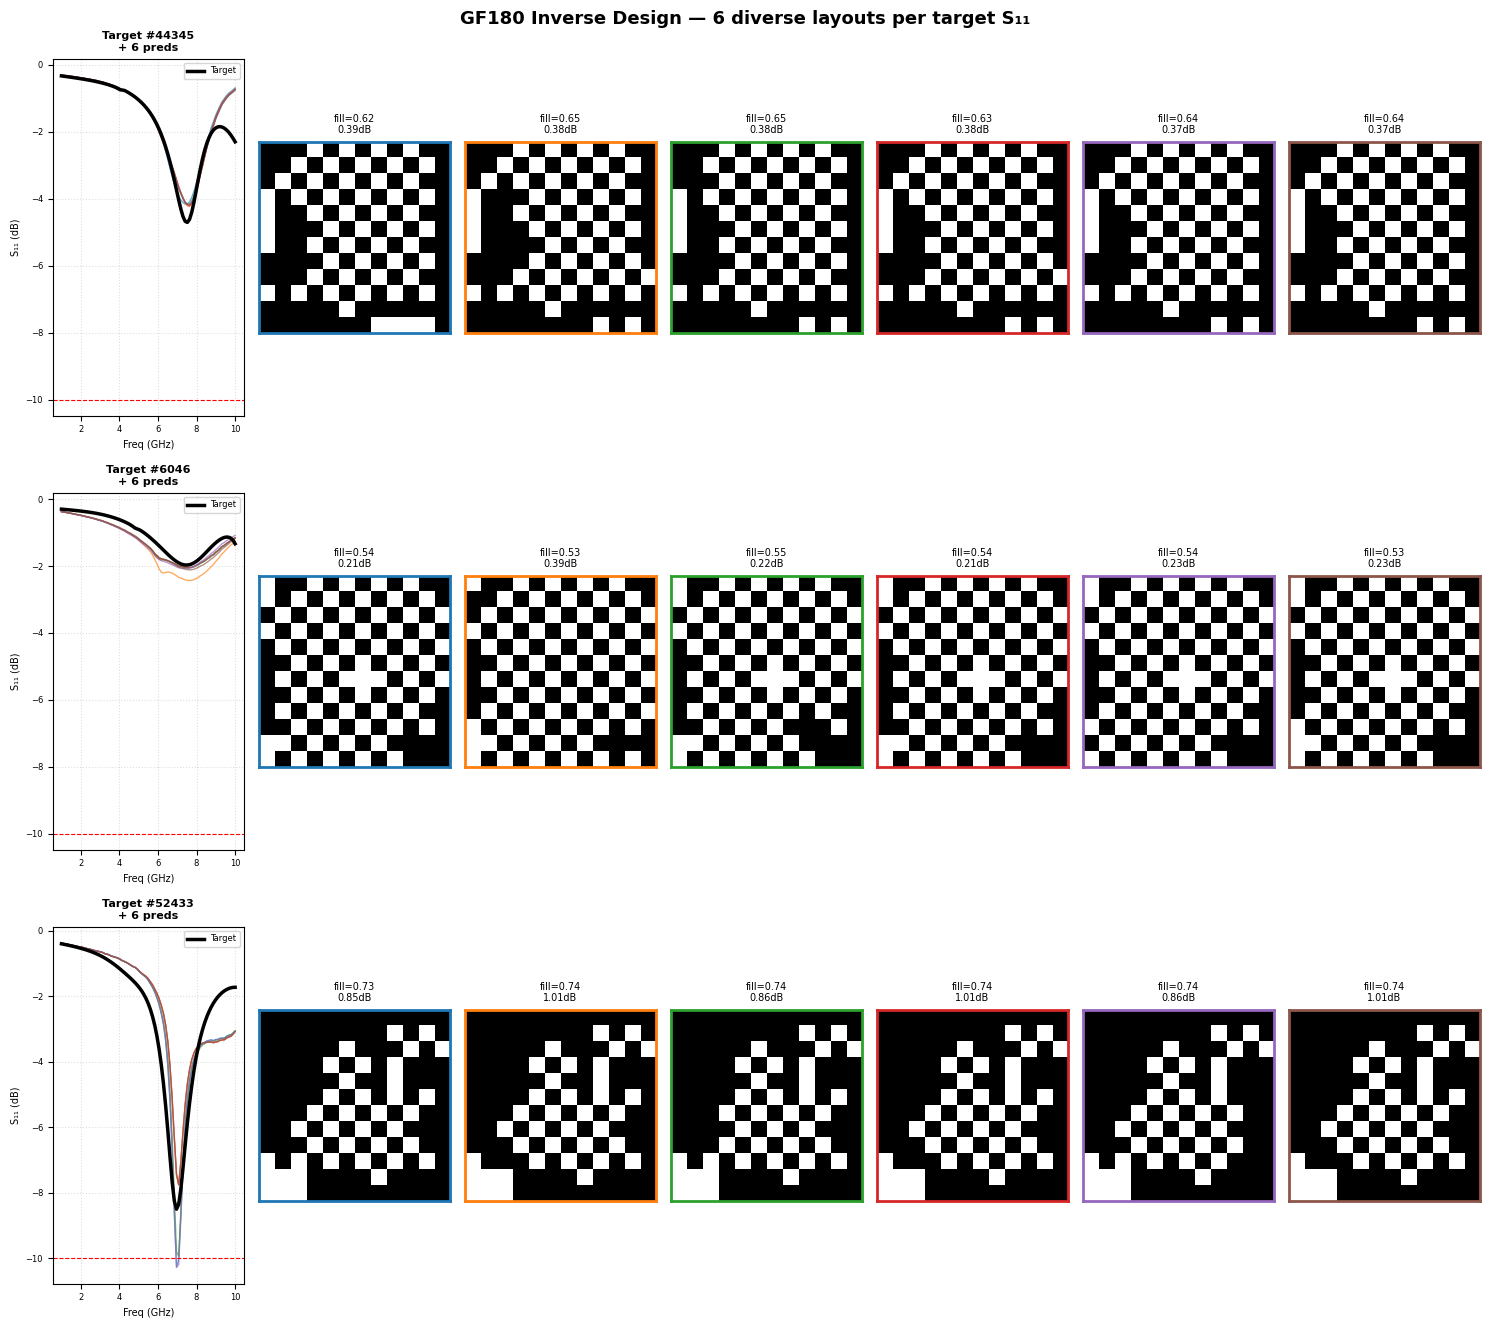

Fill rates per sample: ['0.729', '0.736', '0.736', '0.736', '0.743', '0.736']
Fill std (higher = more diverse): 0.0040  COLLAPSED — all identical!


In [6]:
# ── Diversity evaluation: 6 generated layouts per target ──────────────────────
K_DIV = 6
inv_model.eval()
fwd_model.eval()

rng2     = np.random.default_rng(42)
test_idx = rng2.choice(len(X_test), size=3, replace=False)

fig = plt.figure(figsize=(15, 4.5 * len(test_idx)))
fig.suptitle(f'GF180 Inverse Design — {K_DIV} diverse layouts per target S₁₁',
             fontsize=13, fontweight='bold')

for row, ti in enumerate(test_idx):
    t_s11_n = ((torch.tensor(Y_test[ti]).unsqueeze(0) - Y_mean) / Y_std).clamp(-CLIP_Z, CLIP_Z).to(DEVICE)
    t_s11   = Y_test[ti]

    with torch.no_grad():
        samples  = inv_model.sample(t_s11_n, k=K_DIV)      # (K, 12, 12)
        bins     = (samples > 0.5).float()
        pred_n   = fwd_model(bins).cpu()
        pred_db  = (pred_n * Y_std + Y_mean).numpy()

    bins_np = bins.cpu().numpy()

    ax_s = fig.add_subplot(len(test_idx), K_DIV + 1, row * (K_DIV + 1) + 1)
    ax_s.plot(freqs_ghz, t_s11, color='black', lw=2.5, label='Target', zorder=5)
    for k in range(K_DIV):
        ax_s.plot(freqs_ghz, pred_db[k], alpha=0.65, lw=1.0, color=plt.cm.tab10(k))
    ax_s.axhline(-10, color='red', ls='--', lw=0.8)
    ax_s.set_xlabel('Freq (GHz)', fontsize=7); ax_s.set_ylabel('S₁₁ (dB)', fontsize=7)
    ax_s.set_title(f'Target #{ti}\n+ {K_DIV} preds', fontsize=8, fontweight='bold')
    ax_s.legend(fontsize=6); ax_s.grid(True, ls=':', alpha=0.4); ax_s.tick_params(labelsize=6)

    for k in range(K_DIV):
        ax_px = fig.add_subplot(len(test_idx), K_DIV + 1, row * (K_DIV + 1) + k + 2)
        ax_px.imshow(bins_np[k], cmap='binary', vmin=0, vmax=1, interpolation='nearest')
        for sp in ax_px.spines.values(): sp.set_edgecolor(plt.cm.tab10(k)); sp.set_linewidth(2)
        rmse = float(((pred_db[k] - t_s11)**2).mean()**0.5)
        ax_px.set_title(f'fill={bins_np[k].mean():.2f}\n{rmse:.2f}dB', fontsize=7)
        ax_px.set_xticks([]); ax_px.set_yticks([])

plt.tight_layout()
plt.savefig(NB_DIR / 'fig_gf180_diversity.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Fill rate diversity check (all samples identical = collapse) ───────────────
fills = bins_np.mean(axis=(1, 2))
print(f'Fill rates per sample: {[f"{f:.3f}" for f in fills]}')
print(f'Fill std (higher = more diverse): {fills.std():.4f}  '
      f'{"OK" if fills.std() > 0.01 else "COLLAPSED — all identical!"}')


In [7]:
# ── Touchstone export (scikit-rf) — only if FDTD ran ──────────────────────────
import skrf as rf

if fdtd_actual is not None:
    s_mat = np.zeros((N_FREQ, 1, 1), dtype=complex)
    s_mag = 10 ** (fdtd_actual / 20)
    s_mat[:, 0, 0] = s_mag
    net = rf.Network(f=fdtd_f_actual / 1e9, s=s_mat, z0=50, f_unit='GHz',
                     name='GF180_PixelatedRF_actual')
    s1p_path = NB_DIR / 'gf180_actual.s1p'
    net.write_touchstone(str(s1p_path))
    print(f'Touchstone saved: {s1p_path}')
    print(f'Network: {net.f[0]/1e9:.2f}–{net.f[-1]/1e9:.2f} GHz  '
          f'min S11: {fdtd_actual.min():.1f} dB')
    resonant_bands = fdtd_f_actual[fdtd_actual < -10] / 1e9
    if len(resonant_bands):
        print(f'Resonant bands (S11 < -10 dB): {resonant_bands[0]:.2f}–{resonant_bands[-1]:.2f} GHz')
    else:
        print('No resonant band (S11 < -10 dB) in 1–10 GHz — try adjusting PIXEL_UM')
else:
    print('FDTD not run — Touchstone export skipped.')

Touchstone saved: /home/irman/Gelochip/notebooks/pixelatedRF/gf180_actual.s1p
Network: 1.00–10.00 GHz  min S11: -8.0 dB
No resonant band (S11 < -10 dB) in 1–10 GHz — try adjusting PIXEL_UM
